# Chapter 5 — Decision Trees

> *Hands-On Machine Learning with Scikit-Learn, Keras & PyTorch* — Aurélien Géron (2025)

---

In [20]:
import sys
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scikit-Learn
from sklearn.datasets import load_iris, make_moons, make_regression
from sklearn.tree import (DecisionTreeClassifier, DecisionTreeRegressor,
                           export_graphviz, plot_tree)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler

# Reproducibility
np.random.seed(42)

# Shared data path — works from any chapter subfolder
DATA_PATH = Path('../data')

## Training and Visualizing a Decision Tree

In [21]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X_iris = iris.data[['sepal length (cm)', 'sepal width (cm)']].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file='iris_tree.dot',
    feature_names=['sepal length (cm)', 'sepal width (cm)'],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

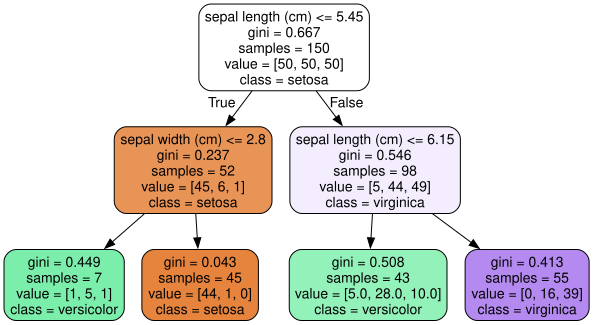

In [4]:
from graphviz import Source

Source.from_file("iris_tree.dot")

## Making Predictions

la gini impurity se calcula como:
$$G = 1 - \sum_{k=1}^{n} p_k^2$$

donde $p_k$ es la proporción de muestras que pertenecen a la clase $k$ en el nodo.


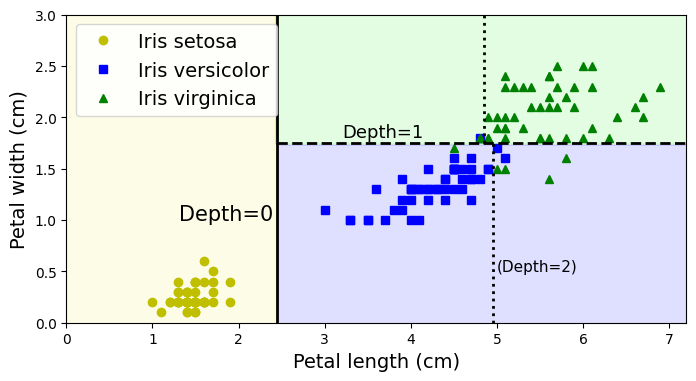

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# extra code – just formatting details
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])
plt.figure(figsize=(8, 4))

lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]
y_pred = tree_clf.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

# extra code – this section beautifies Figure 5–2
tree_clf_deeper = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf_deeper.fit(X_iris, y_iris)
th0, th1, th2a, th2b = tree_clf_deeper.tree_.threshold[[0, 2, 3, 6]]
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.plot([th0, th0], [0, 3], "k-", linewidth=2)
plt.plot([th0, 7.2], [th1, th1], "k--", linewidth=2)
plt.plot([th2a, th2a], [0, th1], "k:", linewidth=2)
plt.plot([th2b, th2b], [th1, 3], "k:", linewidth=2)
plt.text(th0 - 0.05, 1.0, "Depth=0", horizontalalignment="right", fontsize=15)
plt.text(3.2, th1 + 0.02, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.text(th2a + 0.05, 0.5, "(Depth=2)", fontsize=11)
plt.axis([0, 7.2, 0, 3])
plt.legend()

plt.show()

## Estimating Class Probabilities

In [ ]:
tree_clf.predict_proba([[5, 1.5]]).round(3)

array([[0.143, 0.714, 0.143]])

In [7]:
tree_clf.predict([[5, 1.5]])

array([1])

## The CART Training Algorithm

🌳 Entendiendo la Función de Costo CARTImagina que eres un organizador de eventos y tienes un grupo de 100 personas mezcladas (algunas aman el rock y otras el pop). Tu misión es dividirlas en dos salas diferentes, pero quieres que cada sala sea lo más "pura" posible (que no haya mezclas).La fórmula CART es la herramienta que usas para decidir dónde poner la pared divisoria.La Fórmula MatemáticaPara un par determinado de (característica $k$, umbral $t_k$), el costo se calcula así:$$J(k, t_k) = \frac{m_{\text{izq}}}{m} G_{\text{izq}} + \frac{m_{\text{der}}}{m} G_{\text{der}}$$¿Qué significa cada pieza? 🤔No la veas como una ecuación rígida, mírala como un promedio ponderado de suciedad.1. Las Proporciones ($\frac{m_{\text{izq}}}{m}$ y $\frac{m_{\text{der}}}{m}$)$m$ es el total de personas.$m_{\text{izq}}$ y $m_{\text{der}}$ son cuántas personas terminaron en cada sala.Intuición: Estas fracciones le dicen al algoritmo: 
"Dale más importancia a la sala que tenga más gente". No sirve de nada limpiar perfectamente una sala donde solo hay 1 persona si la sala con 99 personas sigue siendo un caos total.2. La Impureza de Gini ($G_{\text{izq}}$ y $G_{\text{der}}$)Es el nivel de "mezcla" o "suciedad" en cada sala.Si una sala tiene 100% fans de rock, su $G$ es 0 (Pureza total).Si está mitad y mitad, su $G$ es alto (Caos total).

## Computational Complexity

El rendimiento de un Árbol de Decisión se divide en dos fases: **Predicción** (muy rápida) y **Entrenamiento** (más costosa).

---

### 1. Fase de Predicción: $O(\log_2(m))$
Para clasificar una nueva instancia, el modelo recorre el árbol desde la raíz hasta una hoja.
* **Eficiencia:** El tiempo es proporcional al logaritmo del número de instancias de entrenamiento ($m$). 
* **Independencia:** Es **independiente del número de características ($n$)**, ya que en cada nodo solo se evalúa una variable.
* **Ejemplo:** Si entrenaste con 1,000,000 de muestras, el árbol tendrá una profundidad de ~20. Predecir solo requiere 20 comparaciones de "sí/no".

### 2. Fase de Entrenamiento: $O(n \times m \log_2(m))$
El algoritmo CART es exhaustivo porque busca el mejor corte en cada nivel.
* **Costo:** Compara **todas** las características ($n$) en **todas** las muestras ($m$) en cada nodo.
* **Escalabilidad:** Si el dataset es muy grande o tiene miles de columnas, el tiempo de entrenamiento crecerá significativamente.

---

### 🛠️ Control de Velocidad y Overfitting

Puedes optimizar el tiempo de entrenamiento y mejorar la generalización ajustando estos hiperparámetros:

| Hiperparámetro | Impacto en Complejidad | Función |
| :--- | :--- | :--- |
| `max_depth` | ⬇️ Reduce profundidad | Evita que el árbol crezca indefinidamente (Overfitting). |
| `max_features` | ⬇️ Reduce $n$ evaluado | Elige un subconjunto aleatorio de variables en cada nodo. |
| `min_samples_leaf` | ⬇️ Limita divisiones | Asegura que cada hoja tenga un mínimo de muestras. |

> **Nota:** Limitar la complejidad no solo acelera el modelo, sino que lo obliga a aprender patrones generales en lugar de memorizar el ruido de los datos.


## Gini vs. Entropía

La ecuación de la impureza de Gini es:
$$G = 1 - \sum_{k=1}^{n} p_k^2$$
donde $p_k$ es la proporción de muestras que pertenecen a la clase $k$ en el nodo.

La fórmula de la entropía es:
$$H = -\sum_{k=1}^{n} p_k \log_2(p_k)$$
donde $p_k$ es la proporción de muestras que pertenecen a la clase $k$ en el nodo.

## Regularization Hyperparameters

## Idea clave
Los árboles de decisión son **modelos no paramétricos**, lo que significa que:
- No tienen un número fijo de parámetros.
- Pueden crecer libremente y ajustarse demasiado a los datos (overfitting).

En contraste:
- Los modelos **paramétricos** (como regresión lineal) tienen estructura fija.
- Menor riesgo de overfitting, pero mayor riesgo de underfitting.

---

## Problema
Si no se restringe el árbol:
- Se ajusta demasiado a los datos de entrenamiento.
- Pierde capacidad de generalización.

---

## Solución: Regularización

Consiste en limitar la complejidad del árbol usando hiperparámetros.

---

## Hiperparámetros principales

### Control de tamaño del árbol
- `max_depth`: profundidad máxima del árbol  
  - menor valor reduce overfitting  
- `max_leaf_nodes`: número máximo de hojas

### Control de divisiones
- `min_samples_split`: mínimo de muestras para dividir un nodo
- `min_samples_leaf`: mínimo de muestras en una hoja
- `min_weight_fraction_leaf`: versión ponderada del anterior

### Control de features
- `max_features`: número máximo de variables consideradas por split  
  - útil en datasets de alta dimensión

### Control de calidad de split
- `min_impurity_decrease`: mínimo descenso de impureza requerido

### Poda (pruning)
- `ccp_alpha`: controla la poda por complejidad  
  - mayor valor produce un árbol más pequeño y simple

---

## Reglas prácticas

- Para reducir overfitting:
  - disminuir `max_depth`, `max_leaf_nodes`
  - aumentar `min_samples_*`, `ccp_alpha`

- Buenas prácticas:
  - `max_depth`: primer hiperparámetro a ajustar
  - `min_samples_leaf`: importante en datasets pequeños
  - `max_features`: útil en datasets con muchas variables

---

## Conclusión
La regularización en árboles de decisión consiste en restringir su crecimiento para lograr:
- Mejor generalización
- Menor overfitting
- Modelos más interpretables


In [4]:
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier

X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=53)

tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)
tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


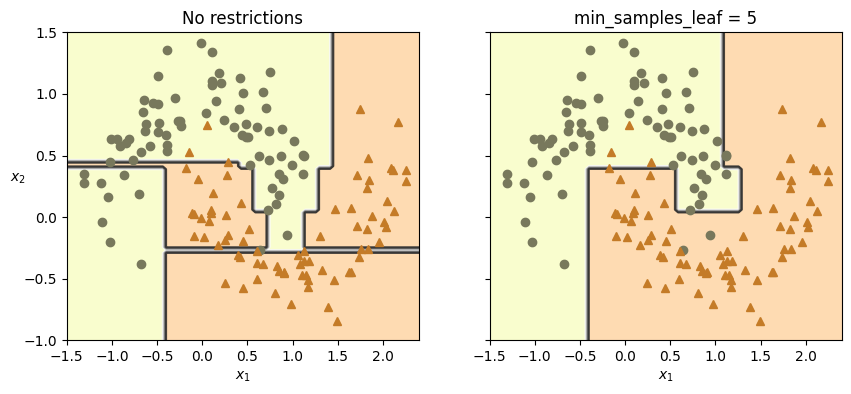

In [7]:
# extra code – this cell generates Figure 5–3
import matplotlib.pyplot as plt
import numpy as np

def plot_decision_boundary(clf, X, y, axes, cmap):
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=cmap)
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8)
    colors = {"Wistia": ["#78785c", "#c47b27"], "Pastel1": ["red", "blue"]}
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[cmap][idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf1, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title("No restrictions")
plt.sca(axes[1])
plot_decision_boundary(tree_clf2, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title(f"min_samples_leaf = {tree_clf2.min_samples_leaf}")
plt.ylabel("")

plt.show()

In [14]:
X_moons_test, y_moons_test = make_moons(n_samples=2000, noise=0.2, random_state=43)

In [15]:
tree_clf1.score(X_moons_test, y_moons_test)

0.935

In [16]:
tree_clf2.score(X_moons_test, y_moons_test)

0.943

## Regression

In [18]:
from sklearn.tree import DecisionTreeRegressor

rng = np.random.default_rng(42)

X_quad = rng.random((200, 1)) - 0.5
y_quad = X_quad ** 2 + 0.025 * rng.standard_normal((200, 1))

tree_reg = DecisionTreeRegressor(random_state=42, max_depth=2)
tree_reg.fit(X_quad, y_quad)


,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


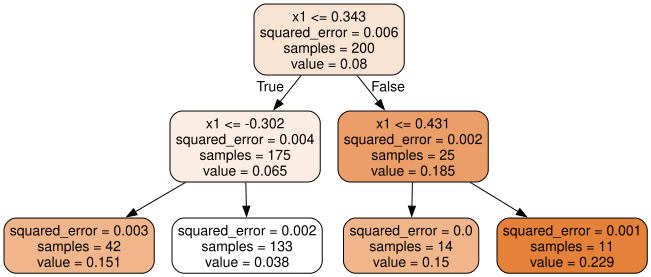

In [24]:
from graphviz import Source

# extra code – we've already seen how to use export_graphviz()
export_graphviz(
    tree_reg,
    out_file="my_regression_tree.dot",
    feature_names=["x1"],
    rounded=True,
    filled=True
)
Source.from_file("my_regression_tree.dot")

In [25]:
tree_reg2 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_reg2.fit(X_quad, y_quad)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [27]:
tree_reg2.tree_.threshold

array([ 0.34304063, -0.30182856, -0.41395289, -2.        , -2.        ,
        0.21817657, -2.        , -2.        ,  0.43140428,  0.39480372,
       -2.        , -2.        ,  0.46470371, -2.        , -2.        ])

## Árboles de Decisión para Regresión (Algoritmo CART)

Cuando un Árbol de Decisión se usa para **Regresión**, el algoritmo CART funciona de manera casi idéntica a la clasificación, pero cambia su métrica de éxito: en lugar de buscar "pureza" (Gini), busca **minimizar el error cuadrático**.

---

### 1. La Función de Costo: MSE en lugar de Gini
El algoritmo busca el par (característica $k$, umbral $t_k$) que minimice la siguiente función:

$$J(k, t_k) = \frac{m_{\text{izq}}}{m} \text{MSE}_{\text{izq}} + \frac{m_{\text{der}}}{m} \text{MSE}_{\text{der}}$$

Donde el **MSE (Error Cuadrático Medio)** en cada nodo se calcula como:
$$\text{MSE}_{\text{nodo}} = \frac{\sum_{i \in \text{nodo}} (\hat{y}_{\text{nodo}} - y^{(i)})^2}{m_{\text{nodo}}}$$

### 2. ¿Cómo predice el valor? ($\hat{y}_{\text{nodo}}$)
A diferencia de la clasificación (donde se elige la clase mayoritaria), en regresión el valor predicho para un nodo es simplemente el **promedio de los valores** de todas las instancias que cayeron en él:

$$\hat{y}_{\text{nodo}} = \frac{\sum_{i \in \text{nodo}} y^{(i)}}{m_{\text{nodo}}}$$

---

### 3. Intuición Visual
* **El Corte:** El árbol intenta dividir los datos en regiones de tal manera que los valores de $y$ dentro de cada región sean lo más parecidos entre sí (poca varianza).
* **La Predicción:** Si una nueva instancia cae en una hoja, el árbol le asigna el promedio de esa "caja". Esto resulta en una predicción que parece una **escalera** o una función constante a trozos, en lugar de una línea curva suave.



> **Nota Clave:** Al igual que en clasificación, el algoritmo es **codicioso (greedy)**: busca el corte que reduce más el MSE *en ese momento*, sin planear si eso ayudará en niveles más profundos.

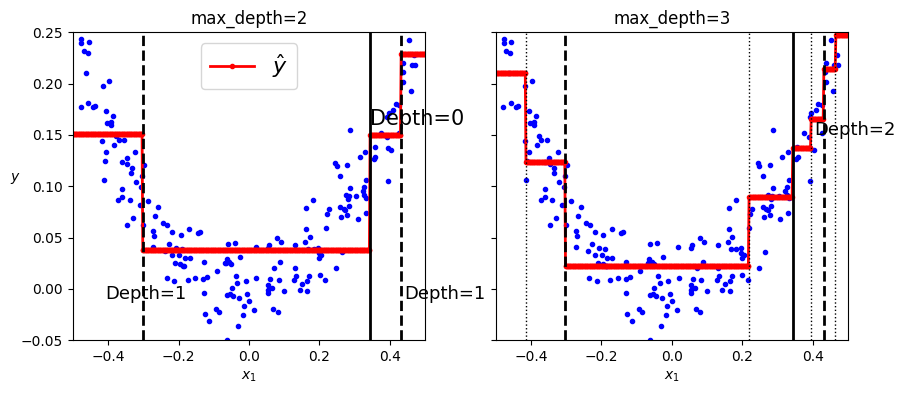

In [28]:
# extra code – this cell generates Figure 5–5

def plot_regression_predictions(tree_reg, X, y, axes=[-0.5, 0.5, -0.05, 0.25]):
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x1)
    plt.axis(axes)
    plt.xlabel("$x_1$")
    plt.plot(X, y, "b.")
    plt.plot(x1, y_pred, "r.-", linewidth=2, label=r"$\hat{y}$")

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_regression_predictions(tree_reg, X_quad, y_quad)

th0, th1a, th1b = tree_reg.tree_.threshold[[0, 1, 4]]
for split, style in ((th0, "k-"), (th1a, "k--"), (th1b, "k--")):
    plt.plot([split, split], [-0.05, 0.25], style, linewidth=2)
plt.text(th0, 0.16, "Depth=0", fontsize=15)
plt.text(th1a + 0.01, -0.01, "Depth=1", horizontalalignment="center", fontsize=13)
plt.text(th1b + 0.01, -0.01, "Depth=1", fontsize=13)
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center", fontsize=16)
plt.title("max_depth=2")

plt.sca(axes[1])
th2s = tree_reg2.tree_.threshold[[2, 5, 9, 12]]
plot_regression_predictions(tree_reg2, X_quad, y_quad)
for split, style in ((th0, "k-"), (th1a, "k--"), (th1b, "k--")):
    plt.plot([split, split], [-0.05, 0.25], style, linewidth=2)
for split in th2s:
    plt.plot([split, split], [-0.05, 0.25], "k:", linewidth=1)
plt.text(th2s[2] + 0.01, 0.15, "Depth=2", fontsize=13)
plt.title("max_depth=3")

plt.show()

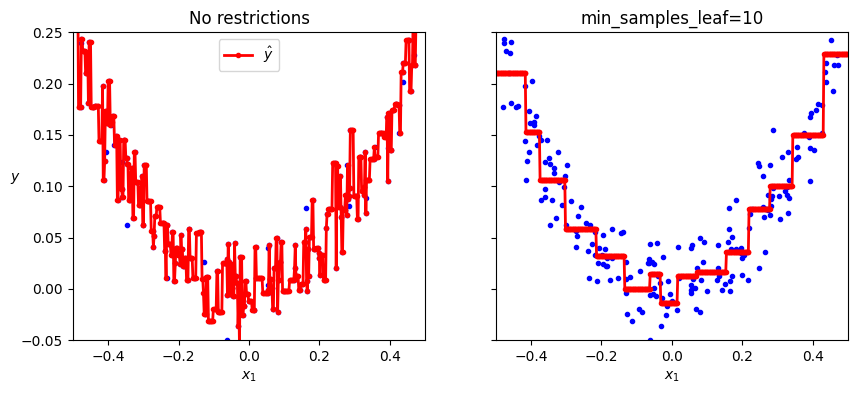

In [33]:
# extra code – this cell generates Figure 5–6

tree_reg1 = DecisionTreeRegressor(random_state=42)
tree_reg2 = DecisionTreeRegressor(random_state=42, min_samples_leaf=10)
tree_reg1.fit(X_quad, y_quad)
tree_reg2.fit(X_quad, y_quad)

x1 = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)
y_pred1 = tree_reg1.predict(x1)
y_pred2 = tree_reg2.predict(x1)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

plt.sca(axes[0])
plt.plot(X_quad, y_quad, "b.")
plt.plot(x1, y_pred1, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([-0.5, 0.5, -0.05, 0.25])
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center")
plt.title("No restrictions")

plt.sca(axes[1])
plt.plot(X_quad, y_quad, "b.")
plt.plot(x1, y_pred2, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([-0.5, 0.5, -0.05, 0.25])
plt.xlabel("$x_1$")
plt.title(f"min_samples_leaf={tree_reg2.min_samples_leaf}")

plt.show()

## Sensitivity to Axis Orientation

In [34]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pca_pipeline = make_pipeline(StandardScaler(), PCA())
X_iris_rotated = pca_pipeline.fit_transform(X_iris)
tree_clf_pca = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf_pca.fit(X_iris_rotated, y_iris)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


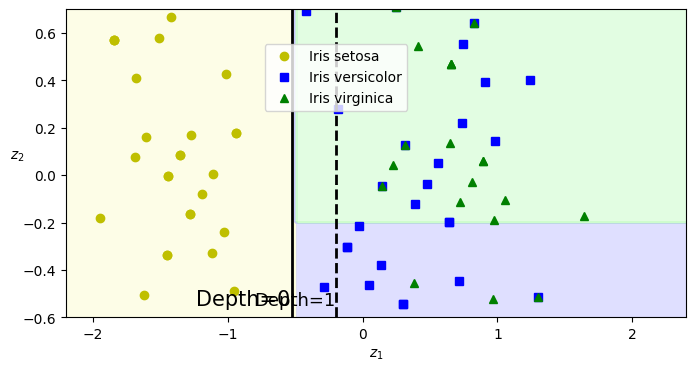

In [37]:
# importar ListedColormap para generar el mapa de colores personalizado
from matplotlib.colors import ListedColormap

# extra code – this cell generates Figure 5–8
custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])
plt.figure(figsize=(8, 4))

axes = [-2.2, 2.4, -0.6, 0.7]
z0s, z1s = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                       np.linspace(axes[2], axes[3], 100))
X_iris_pca_all = np.c_[z0s.ravel(), z1s.ravel()]
y_pred = tree_clf_pca.predict(X_iris_pca_all).reshape(z0s.shape)

plt.contourf(z0s, z1s, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris_rotated[:, 0][y_iris == idx],
             X_iris_rotated[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

plt.xlabel("$z_1$")
plt.ylabel("$z_2$", rotation=0)
th1, th2 = tree_clf_pca.tree_.threshold[[0, 2]]
plt.plot([th1, th1], axes[2:], "k-", linewidth=2)
plt.plot([th2, th2], axes[2:], "k--", linewidth=2)
plt.text(th1 - 0.01, axes[2] + 0.05, "Depth=0",
         horizontalalignment="right", fontsize=15)
plt.text(th2 - 0.01, axes[2] + 0.05, "Depth=1",
         horizontalalignment="right", fontsize=13)
plt.axis(axes)
plt.legend(loc=(0.32, 0.67))

plt.show()

## Decision Trees Have a High Variance

We've seen that small changes in the dataset (such as a rotation) may produce a very different Decision Tree.
Now let's show that training the same model on the same data may produce a very different model every time, since the CART training algorithm used by Scikit-Learn is stochastic. To show this, we will set `random_state` to a different value than earlier:

In [38]:
tree_clf_tweaked = DecisionTreeClassifier(max_depth=2, random_state=40)
tree_clf_tweaked.fit(X_iris, y_iris)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,40
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


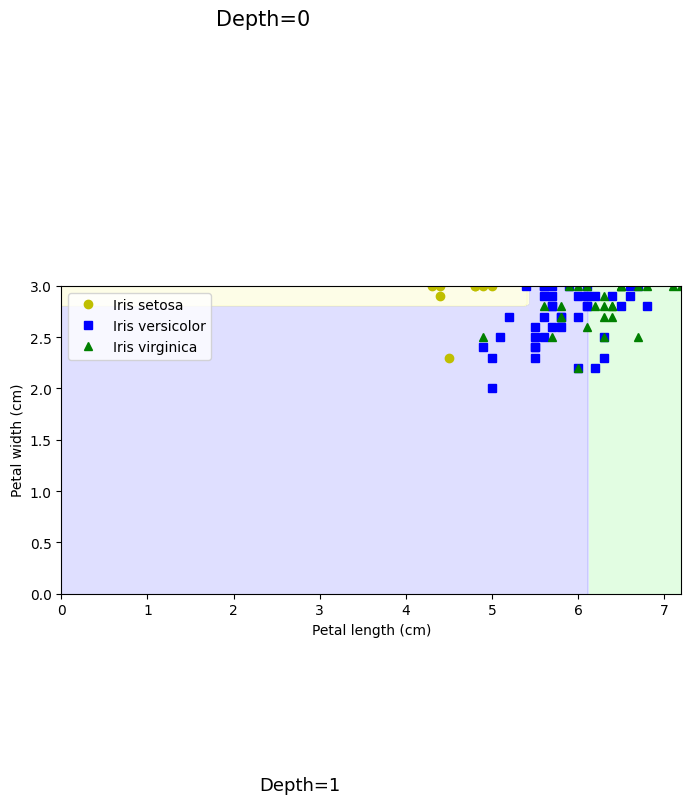

In [41]:
# extra code – this cell generates Figure 5–9
lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]
plt.figure(figsize=(8, 4))
y_pred = tree_clf_tweaked.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)

for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

th0, th1 = tree_clf_tweaked.tree_.threshold[[0, 2]]
plt.plot([0, 7.2], [th0, th0], "k-", linewidth=2)
plt.plot([0, 7.2], [th1, th1], "k--", linewidth=2)
plt.text(1.8, th0 + 0.05, "Depth=0", verticalalignment="bottom", fontsize=15)
plt.text(2.3, th1 + 0.05, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.axis([0, 7.2, 0, 3])
plt.legend()

plt.show()

## Ejercicios

1. ¿Cuál es la profundidad aproximada de un árbol de decisión entrenado sin restricciones sobre un conjunto de entrenamiento con un millón de instancias?

alrededor de un profundidad de 20, crece logaritmicamente por el número de instancias

2. ¿La impureza Gini de un nodo suele ser menor o mayor que la de su nodo padre? ¿Suele ser menor/mayor o siempre menor/mayor?

Suele ser menor por que la idea es encontrar canastas cada vez más puras con el corte de variables y siempre suele ser menor

3. Si un árbol de decisión está sobreajustando el conjunto de entrenamiento, ¿conviene probar a disminuir `max_depth`?

Si esta sobreajustado, conviene reducir la profundidad, para que existan cortes más contundentes que puedan generalizar a datos proximos

4. Si un árbol de decisión está infraajustando el conjunto de entrenamiento, ¿conviene intentar escalar las variables de entrada?

No, escalar variables para arboles no esta necesario en general, unicamente si se usa PCA para rotar variables

5. Si tarda una hora en entrenar un árbol de decisión con un conjunto de entrenamiento de un millón de instancias, ¿cuánto tardará aproximadamente en entrenar otro árbol de decisión con un conjunto de diez millones de instancias?

Muchisimo más, el tiempo aumenta con respecto a logaritmo de la cantidad de instancias, por lo que el tiempo se incrementará significativamente, probablemente en orden de horas o días dependiendo del hardware y la configuración del modelo.

6. Si tarda una hora en entrenar un árbol de decisión sobre un conjunto de entrenamiento dado, ¿cuánto tardará aproximadamente si duplicas el número de características?

Se tardará aproximadamente el doble, ya que el tiempo de entrenamiento es proporcional al número de características ($n$) y al número de instancias ($m$), por lo que si solo se duplica el número de características, el tiempo se incrementará en un factor de 2.

7. Entrena y ajusta finamente un árbol de decisión para el conjunto de datos de las lunas siguiendo estos pasos:
   a. Usa `make_moons(n_samples=10000, noise=0.4)` para generar un conjunto de datos de las lunas.
   b. Usa `train_test_split()` para dividir el conjunto de datos en un conjunto de entrenamiento y un conjunto de prueba.
   c. Usa búsqueda en cuadrícula con validación cruzada, con ayuda de la clase `GridSearchCV`, para encontrar buenos valores de hiperparámetros para un `DecisionTreeClassifier`.
   Pista: prueba varios valores de `max_leaf_nodes`.
   d. Entrénalo sobre todo el conjunto de entrenamiento usando estos hiperparámetros y mide el rendimiento de tu modelo en el conjunto de prueba. Deberías obtener aproximadamente entre 85% y 87% de exactitud.

In [43]:
# iniciamos importando make_moons para generar un conjunto de datos no lineal
from sklearn.datasets import make_moons
# generamos un conjunto de datos con make_moons
X_moons, y_moons = make_moons(n_samples=10000, noise=0.4, random_state=42)

print(f"X_moons shape: {X_moons.shape}")
print(f"y_moons shape: {y_moons.shape}")

X_moons shape: (10000, 2)
y_moons shape: (10000,)


Podemoss continuar usando train_test_split para dividir el conjunto de datos, luego usar GridSearchCV para encontrar los mejores hiperparámetros, y finalmente entrenar el modelo con esos hiperparámetros y evaluar su rendimiento en el conjunto de prueba.

In [45]:
# split
X_train, X_test, y_train, y_test = train_test_split(X_moons, y_moons,
                                                    test_size=0.2,
                                                    random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (8000, 2)
y_train shape: (8000,)
X_test shape: (2000, 2)
y_test shape: (2000,)


In [50]:
# grid search
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 4, 6, 8, 10],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_leaf_nodes': [None, 10, 20, 30]
}

tree_clf = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(estimator=tree_clf, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [2, 4, ...], 'max_leaf_nodes': [None, 10, ...], 'min_samples_leaf': [1, 5, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [51]:
# preds y accuracy
best_tree_clf = grid_search.best_estimator_
y_pred = best_tree_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Best hyperparameters: {grid_search.best_params_}")
print(f"Test set accuracy: {accuracy:.4f}")

Best hyperparameters: {'max_depth': 8, 'max_leaf_nodes': 20, 'min_samples_leaf': 1}
Test set accuracy: 0.8700


8. Haz crecer un bosque siguiendo estos pasos:
   a. Continuando el ejercicio anterior, genera 1.000 subconjuntos del conjunto de entrenamiento, cada uno con 100 instancias seleccionadas al azar. Pista: puedes usar la clase `ShuffleSplit` de Scikit-Learn para esto.
   b. Entrena un árbol de decisión en cada subconjunto, usando los mejores valores de hiperparámetros encontrados en el ejercicio anterior. Evalúa estos 1.000 árboles de decisión en el conjunto de prueba. Como se entrenaron con conjuntos más pequeños, estos árboles probablemente rendirán peor que el primer árbol de decisión, alcanzando solo alrededor de un 80% de exactitud.
   c. Ahora viene la magia. Para cada instancia del conjunto de prueba, genera las predicciones de los 1.000 árboles de decisión y conserva solo la predicción más frecuente (puedes usar la función `mode()` de SciPy para esto). Este enfoque produce predicciones por voto mayoritario sobre el conjunto de prueba.
   d. Evalúa estas predicciones en el conjunto de prueba: deberías obtener una exactitud ligeramente mayor que la de tu primer modelo (aproximadamente entre 0.5% y 1.5% más). ¡Felicidades, has entrenado un clasificador random forest!

In [57]:
from sklearn.model_selection import ShuffleSplit

# 1. Definimos la estrategia: 1000 repartos, cada uno con 100 datos para entrenar
n_trees = 1000
n_instances = 100

from sklearn.datasets import make_moons
# generamos un conjunto de datos con make_moons
X_moons, y_moons = make_moons(n_samples=1000, noise=0.4, random_state=42)

rs = ShuffleSplit(n_splits=n_trees, train_size=n_instances, random_state=42)

# 2. Creamos la lista para almacenar los mini-conjuntos
mini_sets = []

# 3. Iteramos sobre los índices generados
for train_index, _ in rs.split(X_moons):
    X_mini_train = X_moons[train_index]
    y_mini_train = y_moons[train_index]
    mini_sets.append((X_mini_train, y_mini_train))

# Verificación
print(f"Número de mini-sets creados: {len(mini_sets)}")
print(f"Instancias en el primer mini-set: {len(mini_sets[0][0])}")

Número de mini-sets creados: 1000
Instancias en el primer mini-set: 100


In [63]:
# Generar conjunto de test
X_test, y_test = make_moons(n_samples=2000, noise=0.4, random_state=43)

preds = []
for X_mini_train, y_mini_train in mini_sets:
    best_tree_clf.fit(X_mini_train, y_mini_train)
    preds.append(best_tree_clf.predict(X_test))

In [65]:
# importar mode() de scipy para cxrear un unico vector de predicciones
from scipy.stats import mode

# Transponer la lista de predicciones para tener una matriz de shape (n_trees, n_test_instances)
preds_array = np.array(preds).T

# Aplicar mode() a lo largo de las filas para obtener la predicción final por mayoría
final_preds, _ = mode(preds_array, axis=1)
final_preds = final_preds.ravel()  # Aplanar el array de predicciones finales
final_preds

array([1, 1, 0, ..., 0, 0, 1], shape=(2000,))

In [66]:
# calcular la precisión del modelo ensamblado
ensemble_accuracy = accuracy_score(y_test, final_preds)
print(f"Ensemble Test set accuracy: {ensemble_accuracy:.4f}")


Ensemble Test set accuracy: 0.8605
